# Model Comparison

This notebook takes the subset of features chosen in the previous notebook and uses them to train several regression models. The predictive performance of these models is then compared and the chosen model is serialised, ready to be deployed.

The previous notebook selected the following features:
- sqft_living
- latitude
- longitude
- bedrooms
- bathrooms

## Data Loading, Cleaning and Train/Test Splitting

In [1]:
import numpy as np
import pandas as pd

data = pd.read_csv('../data/house_data.csv')  # Load the dataset from the file and store it as a pandas dataframe called data

In [2]:
# Remove instances where bedrooms or bathrooms are 0, these are presumed to be invalid

instances_before = data.shape[0]

data = data[
    (data["bedrooms"] > 0) &
    (data["bathrooms"] > 0)
]

instances_after = data.shape[0]

print(f"Dropped {instances_before-instances_after} invalid instances.")

Dropped 16 invalid instances.


In [3]:
selected_features = [
    "sqft_living",
    "lat",
    "long",
    "bedrooms",
    "bathrooms"
]

y=data['price']               # Create a pandas series (y) to store the prices for all of the houses in the dataset
X=data[selected_features]     # Create a pandas dataframe (X) to store the selected features
X.head()                      # Display the first few rows of the X dataframe along with the column headers

,sqft_living,lat,long,bedrooms,bathrooms
0,1180,47.5112,-122.257,3,1.00
1,2570,47.7210,-122.319,3,2.25
2,770,47.7379,-122.233,2,1.00
3,1960,47.5208,-122.393,4,3.00
4,1680,47.6168,-122.045,3,2.00


In [4]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (with a 70/30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)   

print(f'Training Instances: {X_train.shape[0]} ({(X_train.shape[0]/X.shape[0])*100:.2f}%)')
print(f'Testing Instances:  {X_test.shape[0]} ({(X_test.shape[0]/X.shape[0])*100:.2f}%)')

Training Instances: 15117 (70.00%)
Testing Instances:  6480 (30.00%)


## Multivariate Linear Regression

This model finds an optimal hyperplane (multi-dimensional plane) which fits the training data. The hyperplane is flat and the features are all linear.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import root_mean_squared_error, r2_score

# Ensure all features are of similar scale to prevent larger scale features from dominating the model
lr_model_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()), 
    ("model", LinearRegression())
])

# Fit the model to the training data
lr_model_pipeline.fit(X_train, y_train) 

# Use the trained model to predict the price of the training and testing instances
lr_train_predictions = lr_model_pipeline.predict(X_train)  
lr_test_predictions = lr_model_pipeline.predict(X_test)   

# Calculate and present the training and testing Root Mean Squared Error (RMSE)
# This shows the average error of each prediction as a dollar amount
lr_train_rmse = root_mean_squared_error(y_train, lr_train_predictions) 
lr_test_rmse = root_mean_squared_error(y_test, lr_test_predictions)     

print(f'Train RMSE: ${lr_train_rmse:,.2f}')
print(f'Test RMSE:  ${lr_test_rmse:,.2f}')

# Calculate and present the training and testing R Squared (R2) value
# This shows how much of the variance in house prices is explained by the model
lr_train_r2 = r2_score(y_train, lr_train_predictions)
lr_test_r2 = r2_score(y_test, lr_test_predictions)

print(f"Train R²: {lr_train_r2:.4f}")
print(f"Test R²:  {lr_test_r2:.4f}")

Train RMSE: $233,374.13
Test RMSE:  $238,855.72
Train R²: 0.5855
Test R²:  0.6002


## Polynomial Ridge Regression

The relationship between the selected housing features and sale price is unlikely to be perfectly linear. For example, increasing the floor area of a property from 500 sqft to 1000 sqft may increase its value much more than increasing it from 5000 sqft to 5500 sqft. Polynomial regression addresses this by generating additional features based on higher-order powers of the original features. Other generated features also capture the interactions between original features. These transformations allow linear models to fit a non-linear response surface.

Although polynomial features increase the flexibility of the model, they also increase the risk of overfitting. As the polynomial degree increases, the model can begin fitting noise within the training data rather than learning the general, underlying relationships. The degrees of freedom is a hyperparameter controlling model complexity.

To reduce the risk of overfitting, Ridge Regression is used in place of ordinary linear regression. Ridge Regression adds a penalty term to the loss function which discourages the model from assigning excessively large coefficients to individual features. The objective function has two terms. The first is the Sum of Squared Errors and the second is the sum of squared coefficients (weights excluding the intercept). This second term penalises large coefficient values. The extent to which this penalty affects the model is defined by the tunable alpha parameter. A larger alpha parameter results in the regularisation term having more effect. Excessively large alpha values may lead to the model underfitting.

Selecting an appropriate alpha value is therefore essential in training a good ridge regression model. The RidgeCV algorithm automatically evaluates multiple alpha values using cross-validation on the training set and selects the value that produces the best average validation performance. Cross-validation allows hyperparameter tuning without using the test set, ensuring the test data remains completely unseen until the final model evaluation.

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
import numpy as np

# Test 1-4 degrees of freedom
degrees = [1, 2, 3, 4]
results = []

for d in degrees:
    # Train a polynomial ridge regressor with fixed alpha
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha=1.0
        )) 
    ])
    
    # Use a validation set to evaluate the effect of the DOF change
    # Preserve the actual test set as unseen for the final evaluation
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=5
    )
    
    results.append((d, -scores.mean()))
    
for d, rmse in results:
    print(d, rmse)

1 233484.66327388183
2 231729.18624172598
3 313232.7948416769
4 873897.1868150408


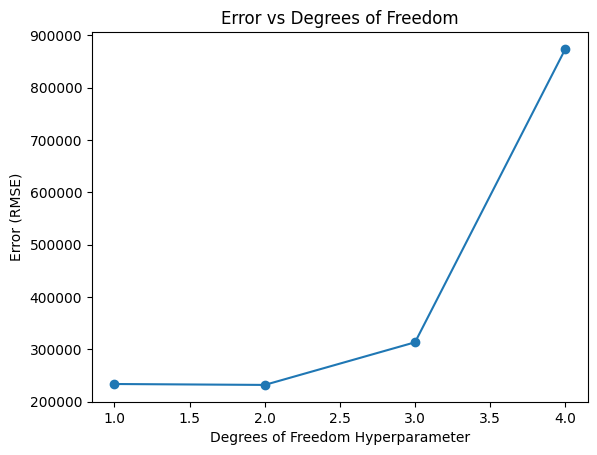

In [7]:
import matplotlib.pyplot as plt

d_vals = [d for d, rmse in results]
rmse_vals = [rmse for d, rmse in results]

plt.plot(d_vals, rmse_vals, marker="o")

plt.title("Error vs Degrees of Freedom")
plt.xlabel("Degrees of Freedom Hyperparameter")
plt.ylabel("Error (RMSE)")        

plt.show()

The above plot shows that 2nd degree polynomial features achieved the lowest cross-validation error in this experiment. Increasing the hyperparameter further leads to worse performance, potentially due to the model overfitting to the noise in the training data rather than capturing the more general relationships.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.metrics import root_mean_squared_error, r2_score

# Optimal number of degrees of freedom determined through tuning
DOF = 2 

# Generate polynomial and interaction features to allows the 
# model to learn non-linear relationships between original features.
# Ensure all features are of similar scale to prevent larger scale features from dominating the model
# Ridge regression to help prevent overfitting
poly_ridge_model_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=DOF)),
    ("scaler", StandardScaler()),
    ("model", RidgeCV(
        alphas=np.logspace(-3, 3, 20)  # Try 20 values 0.001-1000 log scale
    ))
])

# Fit the model to the training data
poly_ridge_model_pipeline.fit(X_train, y_train) 

# Show the alpha value (weight of the regularisation term) chosen through cross validation
print(f"Chosen Alpha: {poly_ridge_model_pipeline.named_steps['model'].alpha_}")

# Use the trained model to predict the price of the training and testing instances
poly_ridge_train_predictions = poly_ridge_model_pipeline.predict(X_train)  
poly_ridge_test_predictions = poly_ridge_model_pipeline.predict(X_test)   

# Calculate and present the training and testing Root Mean Squared Error (RMSE)
# This shows the average error of each prediction as a dollar amount
poly_ridge_train_rmse = root_mean_squared_error(y_train, poly_ridge_train_predictions) 
poly_ridge_test_rmse = root_mean_squared_error(y_test, poly_ridge_test_predictions)     

print(f'Train RMSE: ${poly_ridge_train_rmse:,.2f}')
print(f'Test RMSE:  ${poly_ridge_test_rmse:,.2f}')

# Calculate and present the training and testing R Squared (R2) value
# This shows how much of the variance in house prices is explained by the model
poly_ridge_train_r2 = r2_score(y_train, poly_ridge_train_predictions)
poly_ridge_test_r2 = r2_score(y_test, poly_ridge_test_predictions)

print(f"Train R²: {poly_ridge_train_r2:.4f}")
print(f"Test R²:  {poly_ridge_test_r2:.4f}")

Chosen Alpha: 0.001
Train RMSE: $213,157.74
Test RMSE:  $206,224.63
Train R²: 0.6542
Test R²:  0.7019


Overall this polynomial ridge regression model with 2 degrees of freedom achieved a lower test error than the baseline linear regression model. 

It is worth noting that the degrees of freedom and alpha were tuned in isolation. For unbiased model selection they should be tuned in combination through GridSearchCV so that every combination is tested.

## Random Forest Regression

Random Forest Regressors are an ensemble of decision trees where each tree is trained on a bootstrap sample of the dataset (a random sample of rows drawn with replacement). At each split in a tree, only a random subset of features is considered. The final output is the average of the predictions from all trees. 

Individual decision trees are prone to overfitting, but random forest reduces this by averaging many decorrelated trees. This results in a model with low variance and improved generalisation performance.

In [9]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import root_mean_squared_error, r2_score

# RF is unaffected by feature scaling so no preprocessing is needed in this case
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=2
) 

# Fit the model to the training data
rf_model.fit(X_train, y_train) 

# Use the trained model to predict the price of the training and testing instances
rf_train_predictions = rf_model.predict(X_train)  
rf_test_predictions = rf_model.predict(X_test)   

# Calculate and present the training and testing Root Mean Squared Error (RMSE)
# This shows the average error of each prediction as a dollar amount
rf_train_rmse = root_mean_squared_error(y_train, rf_train_predictions) 
rf_test_rmse = root_mean_squared_error(y_test, rf_test_predictions)     

print(f'Train RMSE: ${rf_train_rmse:,.2f}')
print(f'Test RMSE:  ${rf_test_rmse:,.2f}')

# Calculate and present the training and testing R Squared (R2) value
# This shows how much of the variance in house prices is explained by the model
rf_train_r2 = r2_score(y_train, rf_train_predictions)
rf_test_r2 = r2_score(y_test, rf_test_predictions)

print(f"Train R²: {rf_train_r2:.4f}")
print(f"Test R²:  {rf_test_r2:.4f}")

Train RMSE: $60,512.66
Test RMSE:  $154,262.08
Train R²: 0.9721
Test R²:  0.8332


## Gradient Boosting Regression

Gradient Boosting Regression is an ensemble method that builds a sequence of decision trees where each new tree learns to correct the errors (residuals = differences between predicted and actual values) made by the previous trees. Instead of averaging independent models like Random Forest, it builds models sequentially, with each tree focusing on what the current model is still getting wrong. The contribution of each tree is controlled by a learning rate (a small scaling factor that reduces how much each new tree influences the final model). The number of trees is a key hyperparameter because more trees generally improve performance but increase the risk of overfitting. Overall, Gradient Boosting is powerful because it combines many weak learners (simple trees) into a strong predictive model by iteratively reducing error.

In [10]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, r2_score

# Gradient Boosting model (core hyperparameters tuned lightly)
gb_model_pipeline = Pipeline([
    ("model", GradientBoostingRegressor(
        n_estimators=200,      # number of trees
        learning_rate=0.05,    # shrinkage factor (controls contribution of each tree)
        max_depth=3,           # depth of individual trees (controls complexity)
        random_state=2
    ))
])

# Fit the model to the training data
gb_model_pipeline.fit(X_train, y_train)

# Use the trained model to predict the price of the training and testing instances
gb_train_predictions = gb_model_pipeline.predict(X_train)
gb_test_predictions = gb_model_pipeline.predict(X_test)

# Calculate and present the training and testing Root Mean Squared Error (RMSE)
# This shows the average error of each prediction as a dollar amount
gb_train_rmse = root_mean_squared_error(y_train, gb_train_predictions)
gb_test_rmse = root_mean_squared_error(y_test, gb_test_predictions)

print(f"Train RMSE: ${gb_train_rmse:,.2f}")
print(f"Test RMSE:  ${gb_test_rmse:,.2f}")

# Calculate and present the training and testing R Squared (R2) value
# This shows how much of the variance in house prices is explained by the model
gb_train_r2 = r2_score(y_train, gb_train_predictions)
gb_test_r2 = r2_score(y_test, gb_test_predictions)

print(f"Train R²: {gb_train_r2:.4f}")
print(f"Test R²:  {gb_test_r2:.4f}")

Train RMSE: $156,744.93
Test RMSE:  $165,779.41
Train R²: 0.8130
Test R²:  0.8074


## Log Scale Target Variable Comparison (Experiment)

Due to heavily right-skewed house prices, log transformation lessens the penalising effect of high-price outliers. It does this by predicting proportional error, rather than error in terms of absolute dollar amounts. This means that an error on a $150k house is kept in proportion with an error on a $5M house, rather than harshly punishing mistakes on the outlier prediction.

In [11]:
import numpy as np

y_log = np.log(y)
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

In [12]:
# Fit the model to the training data (LOG PRICES)
lr_model_pipeline.fit(X_train, y_train_log) 

# Use the trained model to predict the price of the training and testing instances
# Immediately convert predicted prices back to the original scale
lr_log_train_predictions = np.exp(lr_model_pipeline.predict(X_train))  
lr_log_test_predictions = np.exp(lr_model_pipeline.predict(X_test))

# Calculate and present the training and testing Root Mean Squared Error (RMSE)
# This shows the average error of each prediction as a dollar amount
lr_log_train_rmse = root_mean_squared_error(y_train, lr_log_train_predictions) 
lr_log_test_rmse = root_mean_squared_error(y_test, lr_log_test_predictions)     

print(f'Train RMSE: ${lr_train_rmse:,.2f} -> ${lr_log_train_rmse:,.2f}')
print(f'Test RMSE:  ${lr_test_rmse:,.2f} -> ${lr_log_test_rmse:,.2f}')

# Calculate and present the training and testing R Squared (R2) value
# This shows how much of the variance in house prices is explained by the model
lr_log_train_r2 = r2_score(y_train, lr_log_train_predictions)
lr_log_test_r2 = r2_score(y_test, lr_log_test_predictions)

print(f"Train R²: {lr_train_r2:.4f} -> {lr_log_train_r2:.4f}")
print(f"Test R²:  {lr_test_r2:.4f} -> {lr_log_test_r2:.4f}")

Train RMSE: $233,374.13 -> $457,773.42
Test RMSE:  $238,855.72 -> $368,547.39
Train R²: 0.5855 -> -0.5949
Test R²:  0.6002 -> 0.0481


Interestingly, the results show that for this model and feature set, predicting log(price) does not actually improve absolute dollar accuracy. This shows that the linear model was already fitting the data well.

## Evaluation and Conclusion

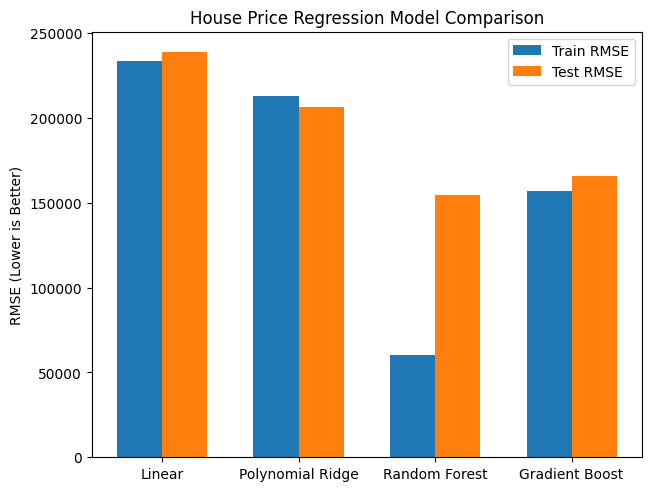

In [13]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ["Linear", "Polynomial Ridge", "Random Forest", "Gradient Boost"]

rmse_vals = {
    "Train RMSE": (lr_train_rmse, poly_ridge_train_rmse, rf_train_rmse, gb_train_rmse),
    "Test RMSE": (lr_test_rmse, poly_ridge_test_rmse, rf_test_rmse, gb_test_rmse)
}    

x = np.arange(len(model_names))  # the label locations
width = 0.33  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, rmse in rmse_vals.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, rmse, width, label=attribute)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('RMSE (Lower is Better)')
ax.set_title('House Price Regression Model Comparison')
ax.set_xticks(x + (width/2), model_names)
ax.legend()

plt.savefig("../images/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": model_names,
    "Train RMSE": [lr_train_rmse, poly_ridge_train_rmse, rf_train_rmse, gb_train_rmse],
    "Test RMSE":  [lr_test_rmse, poly_ridge_test_rmse, rf_test_rmse, gb_test_rmse],
})

results_df.to_csv("../results/model_comparison.csv", index=False)

results_df

,Model,Train RMSE,Test RMSE
0,Linear,233374.131393,238855.720095
1,Polynomial Ridge,213157.736324,206224.626831
2,Random Forest,60512.660042,154262.080010
3,Gradient Boost,156744.926936,165779.410800


Random Forest achieved the lowest test RMSE, indicating the best predictive performance on unseen data, although it shows a large gap between training and test error, suggesting higher variance and a greater tendency to overfit compared to simpler models. 

Gradient boost performed only slightly worse on unseen data but demonstrated a smaller gap between training and test error. In deployment, a model with lower variance is typically more stable and generalises more consistently to new data. Given that the model will be used in a user-facing application where consistency is more important than marginal gains in accuracy, the Gradient Boost model was selected and serialised for deployment.

In [15]:
import joblib

# Save the model so that it can be loaded for use in production
joblib.dump(gb_model_pipeline, "../models/house_price_model.pkl")

['../models/house_price_model.pkl']